# MLR Demo 2 - Model Solution

In [1]:
#
# Import libraries
#
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

## Load data (4212x8)

In [2]:
data = pd.read_csv('gapminder.csv')
# filter data for Asia region only, and drop region column
Asia = data[data.region == 'Asia']
Asia = Asia.drop(columns=['region'], axis=1)
# remove the main dataset (not to use accidentally)
del data
# confirm data dimensions
print('Dataset dimensions:', Asia.shape)
# preview dataset
Asia.head(3)

Dataset dimensions: (4212, 8)


,country,year,population,life_expectancy,age5_surviving,babies_per_woman,gdp_per_capita,gdp_per_day
0,Afghanistan,1800,3280000.0,28.21,53.142,7.0,603.0,1.650924
1,Afghanistan,1810,3280000.0,28.11,53.002,7.0,604.0,1.653662
2,Afghanistan,1820,3323519.0,28.01,52.862,7.0,604.0,1.653662


## Refresher on SLR

In [3]:
#
# Check how life_expectancy depends on age5_surviving in Asia
#

In [4]:
# calculate correlation coefficient
print(Asia['age5_surviving'].corr(Asia['life_expectancy']))

0.9524372701484264


In [5]:
# build SLR
slr=smf.ols('life_expectancy ~ age5_surviving', data = Asia).fit()
# print coefficients
slr.params

Intercept        -30.297220
age5_surviving     1.025894
dtype: float64

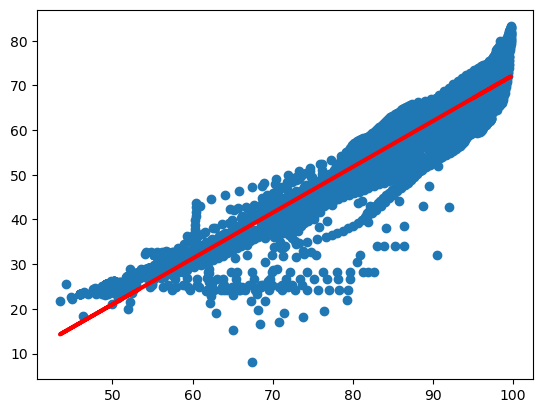

In [6]:
# plot data and the regression line
plt.scatter(Asia['age5_surviving'], Asia['life_expectancy'])
plt.plot(Asia['age5_surviving'], slr.fittedvalues, color='red', linewidth=3)
plt.show()

In [7]:
# print model quality
slr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                 4.113e+04
Date:                Wed, 18 Dec 2024   Prob (F-statistic):               0.00
Time:                        23:21:58   Log-Likelihood:                -12710.
No. Observations:                4212   AIC:                         2.542e+04
Df Residuals:                    4210   BIC:                         2.544e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -30.2972      0.431    -70.270      0.000     -31.143     -29.452
age5_surviving     1.0259      0.005    202.794      0.000       1.016       1.036
==============================================================================
Omnibus:                     1180.586   Durbin-Watson:                   0.115
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4591.387
Skew:                          -1.341   Prob(JB):                         0.00
Kurtosis:                       7.355   Cond. No.                         482.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
#
# CONCLUSION
#
# Since p-value is extremely small, i.e. less than 2e-16
# (in Python it is shown as 0.000),
# variable age5_surviving is significant
#
# Explanatory power of this SLR is 90.7%
#

## Building MLR (4 variables)

In [9]:
#
# Find out how life_expectancy in Asia depends on
# age5_surviving, babies_per_woman, population, gdp_per_day
#

In [10]:
mlr=smf.ols('life_expectancy ~ age5_surviving + babies_per_woman + population + gdp_per_day',
            data = Asia).fit()
mlr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                 1.289e+04
Date:                Wed, 18 Dec 2024   Prob (F-statistic):               0.00
Time:                        23:21:58   Log-Likelihood:                -12273.
No. Observations:                4212   AIC:                         2.456e+04
Df Residuals:                    4207   BIC:                         2.459e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -15.8642      0.686    -23.124      0.000     -17.209     -14.519
age5_surviving       0.9084      0.006    149.309      0.000       0.896       0.920
babies_per_woman    -1.0616      0.049    -21.531      0.000      -1.158      -0.965
population       -7.336e-10   4.28e-10     -1.714      0.087   -1.57e-09    1.05e-10
gdp_per_day          0.0257      0.001     21.020      0.000       0.023       0.028
==============================================================================
Omnibus:                     1576.038   Durbin-Watson:                   0.128
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8827.374
Skew:                          -1.692   Prob(JB):                         0.00
Kurtosis:                       9.233   Cond. No.                     1.72e+09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.72e+09. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
#
# CONCLUSION
#
# Variable population has high p-value: 0.087
# Therefore, it is statistically insignificant - 
# so we are going to exclude it from the model
#
# Notice that explanatory power of this MLR went up to 92.46%
#

## Building MLR (3 variables)

In [12]:
#
# Let's now remove insignificant variable from the model,
# rebuild the model, and check what percentage of data
# new model will explain
#

In [13]:
mlr=smf.ols('life_expectancy ~ age5_surviving + babies_per_woman + gdp_per_day',
            data = Asia).fit()
mlr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                 1.718e+04
Date:                Wed, 18 Dec 2024   Prob (F-statistic):               0.00
Time:                        23:21:58   Log-Likelihood:                -12274.
No. Observations:                4212   AIC:                         2.456e+04
Df Residuals:                    4208   BIC:                         2.458e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -16.0205      0.680    -23.555      0.000     -17.354     -14.687
age5_surviving       0.9087      0.006    149.400      0.000       0.897       0.921
babies_per_woman    -1.0441      0.048    -21.641      0.000      -1.139      -0.950
gdp_per_day          0.0259      0.001     21.397      0.000       0.024       0.028
==============================================================================
Omnibus:                     1566.391   Durbin-Watson:                   0.128
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8717.737
Skew:                          -1.682   Prob(JB):                         0.00
Kurtosis:                       9.193   Cond. No.                         944.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
#
# CONCLUSION
#
# Removing variable population didn't change the quality
# of the model - it still explains 92.45% (ignore rounding)
#

## Display coefficients

In [15]:
mlr.params

Intercept          -16.020508
age5_surviving       0.908678
babies_per_woman    -1.044112
gdp_per_day          0.025914
dtype: float64

## Predictions

In [16]:
#
# Let's calculate predicted value of life_expectancy for
# age5_surviving = 95, babies_per_woman = 2, gdp_per_day = 100
#

In [17]:
# Define inputs
age5_surviving = 95
babies_per_woman = 2
gdp_per_day = 100
#
# Calcualte output:
life_expectancy = 0.908678 * age5_surviving - \
1.044112 * babies_per_woman + 0.025914 * gdp_per_day - 16.020508
print(life_expectancy)
#
# However, it is bad practice to hard-code coefficients into the expression
# should use variables instead:
life_expectancy = \
mlr.params.age5_surviving   * age5_surviving   + \
mlr.params.babies_per_woman * babies_per_woman + \
mlr.params.gdp_per_day      * gdp_per_day      + \
mlr.params.Intercept
print(life_expectancy)

70.80707799999999
70.80707674006693


In [18]:
#
# So MLR predicts life_expectancy to be 70.8 years
#

## SLR vs MLR

In [19]:
#
# Let's predict the same value using SLR
#

In [20]:
age5_surviving = 95
life_expectancy = slr.params.age5_surviving * age5_surviving + slr.params.Intercept
life_expectancy

67.16270752310481

In [21]:
#
# SLR vs MLR predictions:
# 67.2 (SLR) vs 70.8 (MLR)
# Which one do you think is gonna be more reliable?
#

## Visualisation 1 - plotting 3 variables out of 4

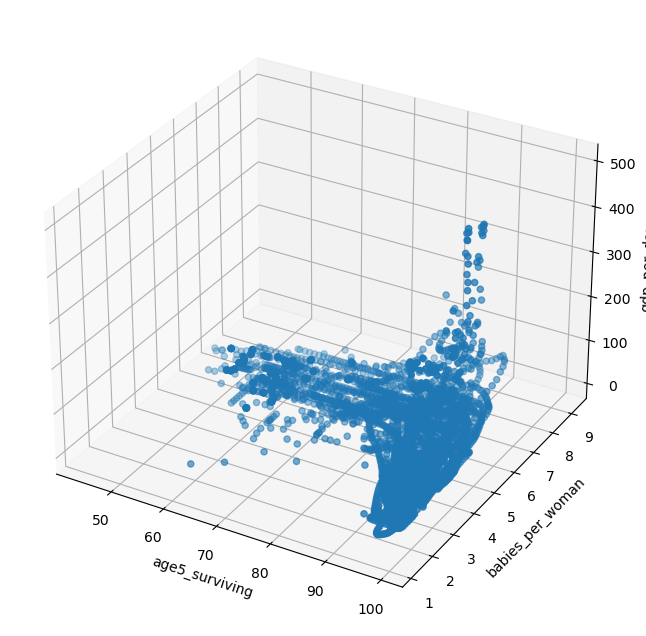

In [22]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Asia.age5_surviving, Asia.babies_per_woman, Asia.gdp_per_day)
ax.set_xlabel('age5_surviving')
ax.set_ylabel('babies_per_woman')
ax.set_zlabel('gdp_per_day')
plt.show()

## Visualisation 2 - plotting all 4 variables

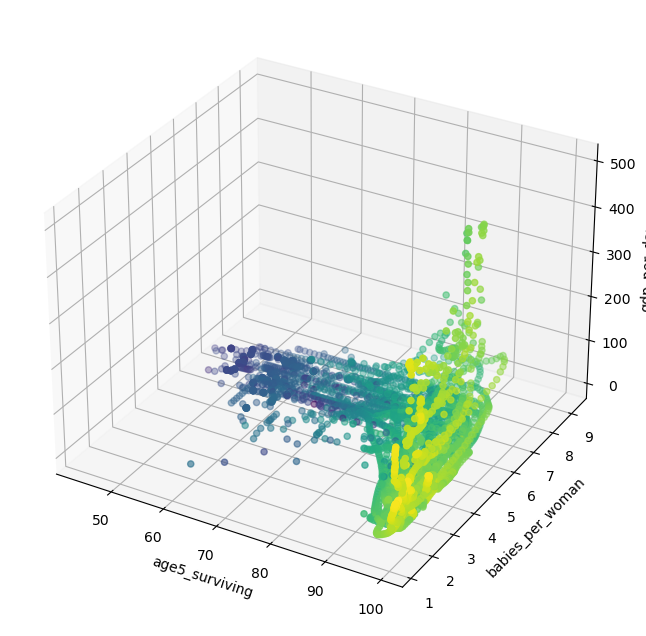

In [23]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Asia.age5_surviving, Asia.babies_per_woman, Asia.gdp_per_day, c=Asia.life_expectancy)
ax.set_xlabel('age5_surviving')
ax.set_ylabel('babies_per_woman')
ax.set_zlabel('gdp_per_day')
plt.show()

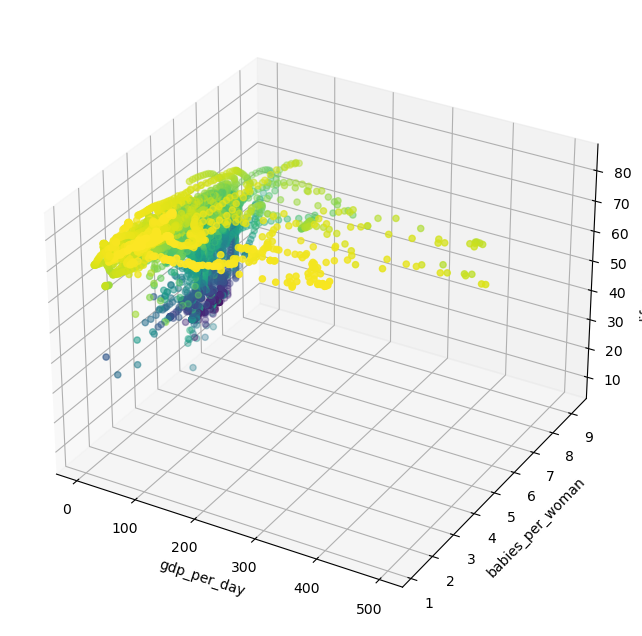

In [24]:
# try swapping axis
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Asia.gdp_per_day, Asia.babies_per_woman, Asia.life_expectancy, c=Asia.age5_surviving)
ax.set_xlabel('gdp_per_day')
ax.set_ylabel('babies_per_woman')
ax.set_zlabel('life_expectancy')
plt.show()